# Regression Model — residuals as the finding
# Notebook by DR

Predicts `cannot_afford` from economic structure, then treats the countries the model gets
wrong as the result: who beats their structure, and who falls short of it.

**Specification**

| | |
|---|---|
| Outcome | `cannot_afford` |
| Estimator | Ridge, linear |
| Sample | Country-level cross-section, latest survey per country, n ≈ 135 |
| CV groups | `region` |
| Quality control | `years_stale` |

**Features (six)**

`gdp_pc_ppp_log`, `urban_share`, `agri_land_share`, `agri_excess`,
`food_production_index`, `fx_volatility_log`

**Excluded deliberately**

`gini_wdi` (73/161 coverage) · `rural_share` (= 100 − urban) ·
`agri_employment_share` (r = 0.81 with agricultural value added) ·
`import_dependence` (costs 11 countries, 8 African — robustness check only)

**Input** `data_cache/target.csv` · **Output** `data_cache/residuals.csv`

## 1. Load

In [ ]:
from google.colab import drive
from pathlib import Path
import shutil

drive.mount('/content/drive')

DRIVE_ZIP = Path('/content/drive/MyDrive/data_cache.zip')
if DRIVE_ZIP.exists():
    shutil.copy(DRIVE_ZIP, Path('data_cache.zip'))
    print('copied data_cache.zip from Drive')

!unzip -q -o data_cache.zip
!ls -lh data_cache

Mounted at /content/drive
copied data_cache.zip from Drive
total 1.9M
-rw-r--r-- 1 root root  17K Sep  9 07:09 countries.csv
-rw-r--r-- 1 root root  21K Sep  9 07:10 coverage_report.csv
-rw-r--r-- 1 root root 340K Sep  9 07:09 fpn.csv
-rw-r--r-- 1 root root 8.3K Sep  9 07:10 import_dependence.csv
-rw-r--r-- 1 root root  47K Sep 10 14:53 model_frame.csv
-rw-r--r-- 1 root root 169K Sep  9 07:09 pip_baseline.csv
-rw-r--r-- 1 root root  40K Sep 10 14:21 pip_target_raw.csv
-rw-r--r-- 1 root root 4.9K Sep  9 07:09 pip_vintage.csv
-rw-r--r-- 1 root root  37K Sep 10 15:13 residuals.csv
-rw-r--r-- 1 root root  78K Sep 10 14:24 target.csv
-rw-r--r-- 1 root root 1.2M Sep  9 07:10 wdi.csv


In [ ]:
from pathlib import Path

CACHE = Path('data_cache')
if not (CACHE / 'target.csv').exists():
    raise FileNotFoundError(
        'target.csv not found. Run 01_build_target.ipynb first and let its final '
        'cell push the updated zip to Drive.')
print('target.csv present')

target.csv present


In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.model_selection import (GroupKFold, KFold, cross_val_predict,
                                     cross_val_score)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')
pd.set_option('display.width', 175)
pd.set_option('display.max_columns', 60)
rng = np.random.default_rng(0)

TARGET = 'cannot_afford'

target   = pd.read_csv(CACHE / 'target.csv')
wdi      = pd.read_csv(CACHE / 'wdi.csv')
impdep   = pd.read_csv(CACHE / 'import_dependence.csv')

print(f'target.csv: {len(target)} rows, {target["iso3"].nunique()} countries')
print(f'flagged is_latest: {target["is_latest"].sum()}')

target.csv: 507 rows, 129 countries
flagged is_latest: 129


## 2. Cross-section

One observation per country, at its most recent household survey.

In [ ]:
cs = target[target['is_latest']].copy()

print(f'cross-section: {len(cs)} countries')
print(f'survey years: {cs["year"].min()}-{cs["year"].max()}')
print()
print(f'{TARGET}:')
print(cs[TARGET].describe().round(4).to_string())
print()
print('countries per region (these are the CV groups):')
print(cs['region'].value_counts().to_string())

cross-section: 129 countries
survey years: 2017-2025

cannot_afford:
count    129.0000
mean       0.3384
std        0.3389
min        0.0000
25%        0.0209
50%        0.2011
75%        0.6586
max        0.9753

countries per region (these are the CV groups):
region
Europe & Central Asia                                43
Sub-Saharan Africa                                   36
Latin America & Caribbean                            18
Middle East, North Africa, Afghanistan & Pakistan    13
East Asia & Pacific                                  11
South Asia                                            6
North America                                         2


## 3. Features

`fx_volatility_log` and `agri_excess` are constructed here. The exchange rate as a level is
not comparable across countries, so its volatility is used, `log1p` transformed to handle
the hyperinflation tail. `agri_excess` is agricultural value added with the part that
merely restates income level removed.

In [ ]:
wdi_w = wdi.pivot_table(index=['iso3', 'year'], columns='indicator',
                        values='value').reset_index()

# FX volatility: dispersion of year-on-year exchange rate movement, per country
fx = wdi_w[['iso3', 'year', 'exchange_rate_lcu_usd']].sort_values(['iso3', 'year']).copy()
fx['pc'] = fx.groupby('iso3')['exchange_rate_lcu_usd'].pct_change()

fxv = fx.groupby('iso3')['pc'].std().rename('fx_vol_raw').reset_index()
fxv['fx_volatility_log'] = np.log1p(fxv['fx_vol_raw'])

print('raw volatility:')
print(fxv['fx_vol_raw'].describe().round(3).to_string())
print()
print('after log1p:')
print(fxv['fx_volatility_log'].describe().round(3).to_string())

raw volatility:
count    212.000
mean       0.271
std        2.096
min        0.000
25%        0.036
50%        0.071
75%        0.084
max       30.111

after log1p:
count    212.000
mean       0.112
std        0.295
min        0.000
25%        0.036
50%        0.069
75%        0.081
max        3.438


In [ ]:
# Covariates matched to each country's own survey year, so predictors and outcome
# describe the same moment. Where a covariate is absent in that year, the nearest
# available year for the same country is substituted rather than dropping the country.
df = cs.merge(wdi_w, on=['iso3', 'year'], how='left')

covars = [x for x in wdi_w.columns if x not in ('iso3', 'year')]
before = df[covars].isna().sum().sum()

for col in covars:
    nearest = (wdi_w.sort_values('year').groupby('iso3')[col]
                    .apply(lambda s: s.ffill().bfill().iloc[-1] if s.notna().any() else np.nan))
    df[col] = df[col].fillna(df['iso3'].map(nearest))

print(f'covariate cells filled from nearest year: {before - df[covars].isna().sum().sum()}')

df = df.merge(fxv[['iso3', 'fx_volatility_log']], on='iso3', how='left')
if 'import_dependence' in impdep.columns:
    df = df.merge(impdep[['iso3', 'import_dependence']], on='iso3', how='left')

covariate cells filled from nearest year: 93


### Note on covariate gap-filling

Predictors are matched to each country's own survey year, so the outcome and the features
describe the same moment. Where an indicator is not published for that exact year, the
nearest available year for the same country is substituted rather than dropping the country.

The figure above counts individual country-indicator **cells**, not countries — an average
of 0.60 filled cells per country.

Most of this traces to World Bank publication lags rather than missing data. Agricultural
land share and the food production index are not yet released for 2025, so every country
with a 2025 survey shows a gap on those two indicators. The substitutions come from 2023 and
2022 respectively.

The approach is acceptable because these are slow-moving structural quantities: agricultural
land share and food production change little year to year, so a two- or three-year
substitution introduces negligible error. It would not be acceptable for a volatile series
such as an exchange rate level, which is why FX enters the model as multi-year volatility
rather than as a point value.

Checked against the reported outliers: four of six rely on no filled covariates at all, and
the remaining two only on the 2025 publication lag described above. GDP per capita, which
carries 74% of the model's coefficient weight, is present for the exact survey year in every
one of the six. The finding does not rest on substituted data.

In [ ]:
df['gdp_pc_ppp_log'] = np.log(df['gdp_pc_ppp'])

# agri_excess: agricultural value added regressed on log GDP per capita, keeping the
# residual. Agricultural share and income level are close to the same measurement
# (r = 0.81 with agricultural employment, which is dropped for that reason), so the
# residual isolates the part income does not already explain.
sub = df[['agri_value_added_share', 'gdp_pc_ppp_log']].dropna()
fit_a = sm.OLS(sub['agri_value_added_share'],
               sm.add_constant(sub['gdp_pc_ppp_log'])).fit()
df.loc[sub.index, 'agri_excess'] = fit_a.resid

print(f'agri_value_added_share ~ gdp_pc_ppp_log : R^2 = {fit_a.rsquared:.3f}')
print(f'  {fit_a.rsquared:.0%} of agricultural share is income level restated;')
print('  agri_excess carries the remainder.')

agri_value_added_share ~ gdp_pc_ppp_log : R^2 = 0.678
  68% of agricultural share is income level restated;
  agri_excess carries the remainder.


In [ ]:
from pathlib import Path
CACHE = Path('data_cache')

FEATURES = ['gdp_pc_ppp_log', 'urban_share', 'agri_land_share', 'agri_excess',
            'food_production_index', 'fx_volatility_log']

mdf = df.dropna(subset=FEATURES + [TARGET]).copy()

print(f'features: {FEATURES}')
print()
print(f'complete cases: {len(mdf)} of {len(df)} countries')
lost = sorted(set(df['iso3']) - set(mdf['iso3']))
if lost:
    print(f'dropped for missing covariates ({len(lost)}): {lost}')
print()
print('regions represented:', mdf['region'].nunique())

mdf.to_csv(CACHE / 'model_frame.csv', index=False)

features: ['gdp_pc_ppp_log', 'urban_share', 'agri_land_share', 'agri_excess', 'food_production_index', 'fx_volatility_log']

complete cases: 128 of 129 countries
dropped for missing covariates (1): ['PSE']

regions represented: 7


## 4. Collinearity

In [ ]:
X = mdf[FEATURES]
Xv = np.column_stack([np.ones(len(X)), X.values])

for i, name in enumerate(['const'] + FEATURES):
    v = variance_inflation_factor(Xv, i)
    note = '   exceeds 10' if (name != 'const' and v > 10) else ''
    print(f'{name:<26} {v:7.2f}{note}')
print()
print('Values are expected to be modest: the feature set was chosen to avoid the')
print('overlaps that ruled out agri_employment_share and rural_share.')

const                         1.00
gdp_pc_ppp_log                2.72
urban_share                   2.44
agri_land_share               1.11
agri_excess                   1.01
food_production_index         1.19
fx_volatility_log             1.09

Values are expected to be modest: the feature set was chosen to avoid the
overlaps that ruled out agri_employment_share and rural_share.


### Reading the VIF table

Variance inflation factor asks how well each feature can be predicted from the others. A
value of 1 means a feature is independent of the rest; higher values mean it duplicates
information already present. Above 5 is a warning, above 10 is a problem — coefficients
become unstable and individually meaningless.

Nothing here exceeds 2.72. GDP per capita and urban share are the two highest, which simply
reflects that richer countries are more urbanised. Well inside acceptable limits.

`agri_excess` at 1.01 is the residualisation working as intended. Agricultural value added
in raw form would have carried most of GDP's signal; regressing it on log GDP and keeping
the residual leaves a variable essentially orthogonal to everything else in the model.

Two variables were excluded ahead of this check rather than tested here: `rural_share`, which
is exactly 100 minus urban share and would be perfectly collinear, and
`agri_employment_share`, which correlates at r = 0.81 with agricultural value added.
`agri_excess` carries that dimension instead.

This result matters for interpreting the coefficients below. GDP goes on to account for
roughly three-quarters of total coefficient magnitude, and a natural first suspicion would be
that the features are competing and the estimator has arbitrarily favoured one. This table
rules that out. The features are not overlapping — income simply carries the signal, and the
others have little independent contribution to make. That is a finding about the data, not an
artifact of the specification.

## 5. Cross-validation: two schemes, two questions

**Region-grouped CV** holds out an entire region per fold. It answers whether the
relationship transfers to regions the model has never seen. That is the right test for a
claim about economic structure in general, and its result is reported as a finding.

It is the wrong basis for judging individual countries. Holding out a whole region forces
extrapolation, so the largest errors land wherever the held-out region was hardest to
reach — which would make the outlier list an artifact of the fold scheme.

**Random 10-fold CV** keeps every region represented in training. It answers how well the
model predicts a country given the relationship as a whole, which is the question the
residual analysis needs.

Both are reported. Residuals in section 6 come from the random folds.

In [ ]:
y = mdf[TARGET]
groups = mdf['region']

ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 60)))

n_reg = mdf['region'].nunique()
gkf = GroupKFold(n_splits=n_reg)
kf = KFold(n_splits=10, shuffle=True, random_state=0)

cv_region = cross_val_score(ridge, X, y, cv=gkf, groups=groups, scoring='r2')
cv_random = cross_val_score(ridge, X, y, cv=kf, scoring='r2')
cv_ols    = cross_val_score(LinearRegression(), X, y, cv=kf, scoring='r2')

print(f'random 10-fold  ridge : R^2 = {cv_random.mean():+.3f}  (sd {cv_random.std():.3f})')
print(f'random 10-fold  OLS   : R^2 = {cv_ols.mean():+.3f}  (sd {cv_ols.std():.3f})')
print()
print('Region-grouped results are reported per fold below, not as a mean. Averaging')
print('across folds lets a single collapsed R^2 denominator dominate the summary.')
print()
print('The random 10-fold figure is the headline generalisation number.')

random 10-fold  ridge : R^2 = +0.810  (sd 0.098)
random 10-fold  OLS   : R^2 = +0.810  (sd 0.099)

Region-grouped results are reported per fold below, not as a mean. Averaging
across folds lets a single collapsed R^2 denominator dominate the summary.

The random 10-fold figure is the headline generalisation number.


### Per-fold detail

R² is measured against each fold's own mean. Where a region's countries cluster tightly,
that denominator is near zero and R² collapses to a large negative number even when
predictions are accurate in absolute terms. MAE carries no such denominator, so reading the
two together separates a variance artifact from a real failure to extrapolate.

Folds smaller than five countries are reported but excluded from the summary range: R² on a
handful of near-identical observations is not a measure of anything.

In [ ]:
from sklearn.metrics import mean_absolute_error

MIN_FOLD = 5   # folds smaller than this are reported but not summarised

print('outcome spread by region:')
print(mdf.groupby('region')[TARGET]
         .agg(['count', 'mean', 'std', 'min', 'max']).round(3).to_string())
print()

fold_rows = []
for tr, te in gkf.split(X, y, groups=groups):
    reg = mdf.iloc[te]['region'].iloc[0]
    m = ridge.fit(X.iloc[tr], y.iloc[tr])
    pr = m.predict(X.iloc[te])
    yt = y.iloc[te]
    fold_rows.append({
        'region': reg,
        'r2': 1 - ((yt - pr) ** 2).sum() / ((yt - yt.mean()) ** 2).sum(),
        'mae': mean_absolute_error(yt, pr),
        'sd_y': yt.std(),
        'n': len(te),
    })
ridge.fit(X, y)

folds = pd.DataFrame(fold_rows).sort_values('n', ascending=False)
folds['summarised'] = folds['n'] >= MIN_FOLD

print(f'{"region held out":<46}{"R2":>10}{"MAE":>9}{"sd(y)":>8}{"n":>5}')
print('-' * 78)
for _, r in folds.iterrows():
    mark = '' if r['summarised'] else '   (too small to summarise)'
    print(f'{r["region"][:45]:<46}{r["r2"]:>10.2f}{r["mae"]:>9.4f}'
          f'{r["sd_y"]:>8.3f}{int(r["n"]):>5}{mark}')

ok = folds[folds['summarised']]
print()
print(f'Folds of at least {MIN_FOLD} countries: {len(ok)} of {len(folds)}')
print(f'  R^2 range : {ok["r2"].min():+.2f} to {ok["r2"].max():+.2f}')
print(f'  MAE range : {ok["mae"].min():.4f} to {ok["mae"].max():.4f}')
print()
print('Report the range, never the mean across folds: one collapsed denominator')
print('dominates any average and makes it meaningless.')

outcome spread by region:
                                                   count   mean    std    min    max
region                                                                              
East Asia & Pacific                                   11  0.326  0.322  0.009  0.795
Europe & Central Asia                                 43  0.057  0.112  0.001  0.545
Latin America & Caribbean                             18  0.257  0.140  0.061  0.547
Middle East, North Africa, Afghanistan & Pakistan     12  0.367  0.348  0.000  0.975
North America                                          2  0.010  0.006  0.006  0.014
South Asia                                             6  0.416  0.269  0.033  0.716
Sub-Saharan Africa                                    36  0.720  0.241  0.056  0.968

region held out                                       R2      MAE   sd(y)    n
------------------------------------------------------------------------------
Europe & Central Asia                             

### Reading the fold table

Three patterns appear, and they mean different things.

**A tiny fold with a huge negative R² and a low MAE** is a measurement artifact, not a model
failure. North America contains two countries whose outcomes differ by less than a
percentage point, so the variance the R² formula divides by is effectively zero — while the
absolute error is the smallest of any fold. The model predicts these countries well. The
statistic simply cannot be computed meaningfully on them.

**A large fold with a positive R² and a mid-range MAE** is the model working. Sub-Saharan
Africa is the largest fold at 36 countries and the highest-unaffordability region, and it is
predicted from the other regions without difficulty. The high end of the range is reachable.

**A large fold where MAE exceeds the region's own spread** is the real limitation. Europe &
Central Asia holds 43 countries clustered near the bottom of the range with a long thin tail.
Once nearly everyone in a region can afford the diet, income stops separating countries and
the model has little left to discriminate on. This is a genuine boundary of the
specification and belongs in the write-up as one, phrased as what the model can and cannot
do rather than as a defect.

In [ ]:
# Small folds carry disproportionate weight in the bootstrap that follows, because a
# resample can easily contain few or none of their countries. Any of these appearing in
# the final outlier list warrants inspection rather than direct reporting.
small = folds[~folds['summarised']]['region'].tolist()
if small:
    watch = mdf[mdf['region'].isin(small)][['iso3', 'country', 'region']]
    print(f'countries in folds under {MIN_FOLD}, to check against the outlier list:')
    print(watch.to_string(index=False))
else:
    print(f'no region holds fewer than {MIN_FOLD} countries')

countries in folds under 5, to check against the outlier list:
iso3       country        region
 CAN        Canada North America
 USA United States North America


### Why small folds are flagged

North America contains only two countries in this sample, and both appear in the fold table
above with an R² of roughly −296 — the number that made the region-grouped average
uninterpretable.

That figure is a measurement artifact, not a model failure. R² measures improvement over
predicting the fold's own mean. Canada and the United States have outcomes differing by less
than a percentage point, so their variance is close to zero, and dividing by it produces an
enormous negative value regardless of how good the predictions are. The absolute error tells
the real story: MAE of 0.0515, the lowest of any fold. The model predicts these two countries
more accurately than anywhere else.

The second reason to flag them concerns the stability test that follows. Bootstrap resampling
draws countries with replacement, so a country from a two-member region will often find
itself resampled with neither of its regional peers present. Its residual moves more between
resamples than a country drawn from a group of forty, which can push it toward the outlier
threshold for reasons of sampling rather than substance.

Neither country is expected to qualify — both sit at the bottom of the outcome range with
high GDP, exactly where the model performs best. The list exists so that if either does
appear among the final outliers, it gets inspected rather than reported at face value.

In [ ]:
fit = ridge.fit(X, y)
alpha = fit.named_steps['ridgecv'].alpha_
coefs = pd.Series(fit.named_steps['ridgecv'].coef_, index=FEATURES)

print(f'selected alpha: {alpha:.4f}')
print()
print('standardised coefficients, comparable in magnitude:')
ranked = coefs.reindex(coefs.abs().sort_values(ascending=False).index)
print(ranked.round(4).to_string())
print()

# Where one feature dominates, the model is effectively univariate and the residuals
# are deviation from that single relationship. Worth stating rather than presenting
# six features as though each contributes.
share = ranked.abs() / ranked.abs().sum()
print('share of total coefficient magnitude:')
print((share * 100).round(1).astype(str).add('%').to_string())
if share.iloc[0] > 0.60:
    print()
    print(f'{ranked.index[0]} carries {share.iloc[0]:.0%} of the total. The model is')
    print('effectively univariate; residuals are departures from that relationship.')
print()

mdf['pred'] = fit.predict(X)
mdf['resid'] = y - mdf['pred']

print(f'in-sample R^2      : {fit.score(X, y):.3f}')
print(f'mean absolute error: {mdf["resid"].abs().mean():.4f}')
print(f'residual sd        : {mdf["resid"].std():.4f}')

selected alpha: 1.1242

standardised coefficients, comparable in magnitude:
gdp_pc_ppp_log          -0.2860
fx_volatility_log        0.0379
agri_excess              0.0270
food_production_index    0.0256
urban_share             -0.0068
agri_land_share          0.0041

share of total coefficient magnitude:
gdp_pc_ppp_log           73.8%
fx_volatility_log         9.8%
agri_excess               7.0%
food_production_index     6.6%
urban_share               1.8%
agri_land_share           1.1%

gdp_pc_ppp_log carries 74% of the total. The model is
effectively univariate; residuals are departures from that relationship.

in-sample R^2      : 0.850
mean absolute error: 0.0994
residual sd        : 0.1316


## 6. Residuals

Out-of-fold predictions are used rather than in-sample ones. An in-sample residual is
partly the model having fitted the country it is now being judged against, which shrinks
every residual toward zero and shrinks high-leverage countries hardest — often the
interesting ones.

The folds are random, not region-grouped, for the reason given in section 5: region
grouping forces extrapolation and would place the largest residuals wherever the held-out
region was hardest to reach, rather than where countries genuinely depart from the
relationship.

In [ ]:
oof = cross_val_predict(ridge, X, y, cv=kf)
mdf['pred_oof'] = oof
mdf['resid_oof'] = y - oof
mdf['resid_z'] = (mdf['resid_oof'] - mdf['resid_oof'].mean()) / mdf['resid_oof'].std()

print('out-of-fold residuals:')
print(mdf['resid_oof'].describe().round(4).to_string())
print()
print(f'out-of-fold R^2: {1 - (mdf["resid_oof"]**2).sum() / ((y - y.mean())**2).sum():.3f}')

out-of-fold residuals:
count    128.0000
mean      -0.0010
std        0.1385
min       -0.3454
25%       -0.0876
50%       -0.0069
75%        0.0740
max        0.3964

out-of-fold R^2: 0.834


## 7. Stability

Roughly a tenth of countries sit far from any fitted line by construction, so ranking by
residual and reporting the extremes would be noise-mining. A country qualifies only if it
stays extreme under resampling and under respecification.

In [ ]:
# Bootstrap over countries. A country extreme in only a minority of resamples is not
# distinguishable from sampling noise.
B = 500
hits = np.zeros(len(mdf))
idx_all = np.arange(len(mdf))

for _ in range(B):
    take = rng.choice(idx_all, len(idx_all), replace=True)
    f_b = ridge.fit(X.iloc[take], y.iloc[take])
    r_b = y - f_b.predict(X)
    hits += (r_b.abs() >= r_b.abs().quantile(0.90)).astype(int).values

mdf['boot_rate'] = hits / B
ridge.fit(X, y)

print(f'{B} bootstrap resamples complete')
print(mdf['boot_rate'].describe().round(3).to_string())

500 bootstrap resamples complete
count    128.000
mean       0.102
std        0.267
min        0.000
25%        0.000
50%        0.000
75%        0.008
max        1.000


In [ ]:
# Each feature dropped in turn, confirming outlier status does not depend on any one
# covariate being present.
spec_hits = np.zeros(len(mdf))

for drop in FEATURES:
    keep = [f for f in FEATURES if f != drop]
    f_s = ridge.fit(mdf[keep], y)
    r_s = y - f_s.predict(mdf[keep])
    spec_hits += (r_s.abs() >= r_s.abs().quantile(0.90)).astype(int).values

mdf['spec_rate'] = spec_hits / len(FEATURES)
mdf['stable'] = (mdf['boot_rate'] >= 0.80) & (mdf['spec_rate'] >= 0.80)
ridge.fit(X, y)

print(f'{len(FEATURES)} alternative specifications fitted')
print(f'{mdf["stable"].sum()} of {len(mdf)} countries remain extreme in at least 80% of')
print('resamples and 80% of specifications.')
print()

# Countries from sparsely populated regions have unusual leverage: a resample may
# contain few or none of their neighbours, so their residuals move more than most.
flagged_small = mdf[mdf['stable'] & mdf['region'].isin(small)]
if len(flagged_small):
    print('From small regions, so worth inspecting before reporting:')
    print(flagged_small[['country', 'region', 'resid_z']].round(3).to_string(index=False))

6 alternative specifications fitted
8 of 128 countries remain extreme in at least 80% of
resamples and 80% of specifications.



## 8. The finding

Split by sign, because the two directions are different findings. Countries below the line
are doing better than their structure predicts; something there is working. Countries above
it are doing worse.

Quality filters applied afterwards, not before: a country resting on a decade-old survey or
on an imputed published figure is flagged rather than silently dropped.

In [ ]:
cols = ['country', 'region', 'income_group', TARGET, 'pred_oof', 'resid_z',
        'boot_rate', 'spec_rate', 'years_stale', 'gap_vs_published']

better = mdf[mdf['stable'] & (mdf['resid_oof'] < 0)]
worse  = mdf[mdf['stable'] & (mdf['resid_oof'] > 0)]

print('BEATS ITS STRUCTURE')
print('observed unaffordability below the level economic structure predicts')
print(better.sort_values('resid_z')[cols].round(3).to_string(index=False))
print()
print('FALLS SHORT OF ITS STRUCTURE')
print('observed unaffordability above the level economic structure predicts')
print(worse.sort_values('resid_z', ascending=False)[cols].round(3).to_string(index=False))

BEATS ITS STRUCTURE
observed unaffordability below the level economic structure predicts
   country                     region        income_group  cannot_afford  pred_oof  resid_z  boot_rate  spec_rate  years_stale  gap_vs_published
Uzbekistan      Europe & Central Asia Lower middle income          0.143     0.488   -2.486      0.996      1.000            1             0.081
    Belize Latin America & Caribbean  Upper middle income          0.070     0.352   -2.034      0.910      0.833            8            -0.147
    Guinea        Sub-Saharan Africa  Lower middle income          0.472     0.733   -1.879      0.858      0.833            8             0.008

FALLS SHORT OF ITS STRUCTURE
observed unaffordability above the level economic structure predicts
          country              region        income_group  cannot_afford  pred_oof  resid_z  boot_rate  spec_rate  years_stale  gap_vs_published
        Indonesia East Asia & Pacific Upper middle income          0.748     0.352    2

In [ ]:
# Deviation attributable to data quality is separated from deviation that supports a
# substantive claim.
flag = mdf[mdf['stable']].copy()
flag['stale_survey'] = flag['years_stale'] > 10
flag['likely_imputed'] = flag['gap_vs_published'].abs() > 0.20
flag['clean'] = ~flag['stale_survey'] & ~flag['likely_imputed']

print(f'stable outliers                  : {len(flag)}')
print(f'  survey older than 10 years     : {flag["stale_survey"].sum()}')
print(f'  published figure likely imputed: {flag["likely_imputed"].sum()}')
print(f'  clean                          : {flag["clean"].sum()}')
print()
if flag['clean'].any():
    print('Countries carrying the finding:')
    print(flag[flag['clean']]
          .sort_values('resid_z')[['country', 'region', TARGET, 'pred_oof', 'resid_z']]
          .round(3).to_string(index=False))
else:
    print('No stable outlier survives the quality filters. Reportable as a result:')
    print('deviations that look substantive are attributable to survey vintage or to')
    print('imputation in the published series.')

stable outliers                  : 8
  survey older than 10 years     : 0
  published figure likely imputed: 2
  clean                          : 6

Countries carrying the finding:
          country                     region  cannot_afford  pred_oof  resid_z
       Uzbekistan      Europe & Central Asia          0.143     0.488   -2.486
           Belize Latin America & Caribbean           0.070     0.352   -2.034
           Guinea        Sub-Saharan Africa           0.472     0.733   -1.879
            Kenya        Sub-Saharan Africa           0.877     0.612    1.919
Equatorial Guinea        Sub-Saharan Africa           0.599     0.248    2.539
        Indonesia        East Asia & Pacific          0.748     0.352    2.868


## 9. Is the linear form costing accuracy?

A gradient boosted model is fitted purely as a diagnostic, never as the reporting model. If
it does not beat ridge out of sample, that comparison converts a possible objection into a
stated result. If it wins substantially, real non-linearity exists and the residuals partly
reflect misspecification rather than country performance — which belongs in the write-up.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbm = GradientBoostingRegressor(random_state=0, n_estimators=300, max_depth=2)
cv_gbm = cross_val_score(gbm, X, y, cv=kf, scoring='r2')

print(f'random 10-fold  ridge   : R^2 = {cv_random.mean():+.3f}')
print(f'random 10-fold  boosted : R^2 = {cv_gbm.mean():+.3f}')
print()
gap = cv_gbm.mean() - cv_random.mean()
if gap > 0.05:
    print(f'The boosted model leads by {gap:.3f}. Non-linearity is present that the')
    print('linear specification misses. Ridge remains the reporting model because a')
    print('residual from an ensemble cannot be interpreted, but this belongs in the')
    print('limitations.')
else:
    print(f'The boosted model does not beat ridge (gap {gap:+.3f}). At this sample size')
    print('the regularised linear model is the right choice, and this comparison is')
    print('itself worth reporting.')

random 10-fold  ridge   : R^2 = +0.810
random 10-fold  boosted : R^2 = +0.790

The boosted model does not beat ridge (gap -0.020). At this sample size
the regularised linear model is the right choice, and this comparison is
itself worth reporting.


## 10. Robustness

Import dependence is excluded from the main fit because requiring it costs 11 countries, 8
of them African — the group the question most concerns. Added back here to confirm the
coefficients hold.

In [ ]:
if 'import_dependence' in mdf.columns:
    F2 = FEATURES + ['import_dependence']
    sub2 = mdf.dropna(subset=F2 + [TARGET])

    print(f'main sample      : {len(mdf)} countries')
    print(f'with import dep. : {len(sub2)} countries')
    lost2 = sorted(set(mdf["iso3"]) - set(sub2["iso3"]))
    print(f'lost ({len(lost2)}): {lost2}')
    print()

    f2 = ridge.fit(sub2[F2], sub2[TARGET])
    c2 = pd.Series(f2.named_steps['ridgecv'].coef_, index=F2)

    print(pd.DataFrame({'main': coefs, 'with_import_dep': c2}).round(4).to_string())
    print()
    print('Coefficients keeping their sign and rough magnitude support the claim that')
    print('excluding import dependence does not distort the main result.')
    ridge.fit(X, y)

main sample      : 128 countries
with import dep. : 120 countries
lost (8): ['BDI', 'BEN', 'CAF', 'GNQ', 'JPN', 'MLI', 'TCD', 'TGO']

                         main  with_import_dep
agri_excess            0.0270           0.0333
agri_land_share        0.0041           0.0067
food_production_index  0.0256           0.0287
fx_volatility_log      0.0379           0.0381
gdp_pc_ppp_log        -0.2860          -0.2750
import_dependence         NaN          -0.0021
urban_share           -0.0068          -0.0072

Coefficients keeping their sign and rough magnitude support the claim that
excluding import dependence does not distort the main result.


## 11. Diagnostics

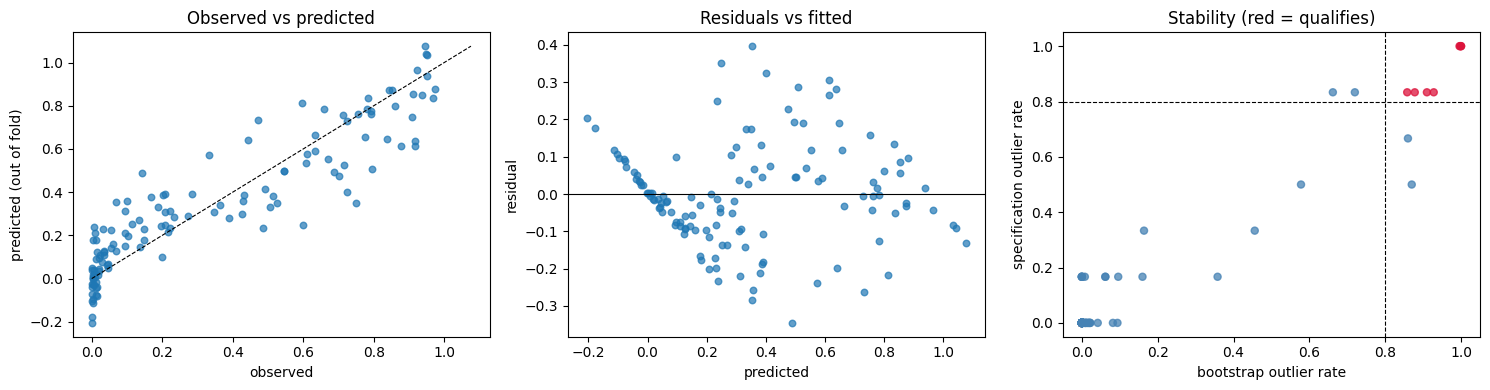

predictions outside [0, 1]: 19 of 128
  Worth noting in the write-up as a limitation of the linear form.


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].scatter(mdf[TARGET], mdf['pred_oof'], s=22, alpha=0.7)
lim = [0, max(mdf[TARGET].max(), mdf['pred_oof'].max())]
ax[0].plot(lim, lim, 'k--', lw=0.8)
ax[0].set_xlabel('observed'); ax[0].set_ylabel('predicted (out of fold)')
ax[0].set_title('Observed vs predicted')

ax[1].scatter(mdf['pred_oof'], mdf['resid_oof'], s=22, alpha=0.7)
ax[1].axhline(0, color='k', lw=0.8)
ax[1].set_xlabel('predicted'); ax[1].set_ylabel('residual')
ax[1].set_title('Residuals vs fitted')

colr = mdf['stable'].map({True: 'crimson', False: 'steelblue'})
ax[2].scatter(mdf['boot_rate'], mdf['spec_rate'], s=26, c=colr, alpha=0.75)
ax[2].axvline(0.80, color='k', ls='--', lw=0.8)
ax[2].axhline(0.80, color='k', ls='--', lw=0.8)
ax[2].set_xlabel('bootstrap outlier rate'); ax[2].set_ylabel('specification outlier rate')
ax[2].set_title('Stability (red = qualifies)')

plt.tight_layout(); plt.show()

# A linear model on a bounded share can predict outside [0, 1]; worth knowing whether
# it does, and for how many countries.
oob = ((mdf['pred_oof'] < 0) | (mdf['pred_oof'] > 1)).sum()
print(f'predictions outside [0, 1]: {oob} of {len(mdf)}')
if oob:
    print('  Worth noting in the write-up as a limitation of the linear form.')

## 12. Presentation figures

Four charts sized for a slide deck, each saved as a 200 dpi PNG. Figure 1 carries the
finding on its own; the rest support it.

In [ ]:
plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

BLUE = '#2166ac'    # beats its structure
RED  = '#b2182b'    # falls short
GREY = '#bdbdbd'

# Clean outliers: stable under both tests, and not attributable to data quality
flag = mdf[mdf['stable']].copy()
flag['stale'] = flag['years_stale'] > 10
flag['imputed'] = flag['gap_vs_published'].abs() > 0.20
clean = flag[~flag['stale'] & ~flag['imputed']].copy()

print(f'{len(clean)} clean outliers to plot')

6 clean outliers to plot


### Figure 1 — What income predicted, and what happened

A hollow dot marks the prediction, a filled dot the observation, and the line between them
is the gap. Readable without any explanation of the model.

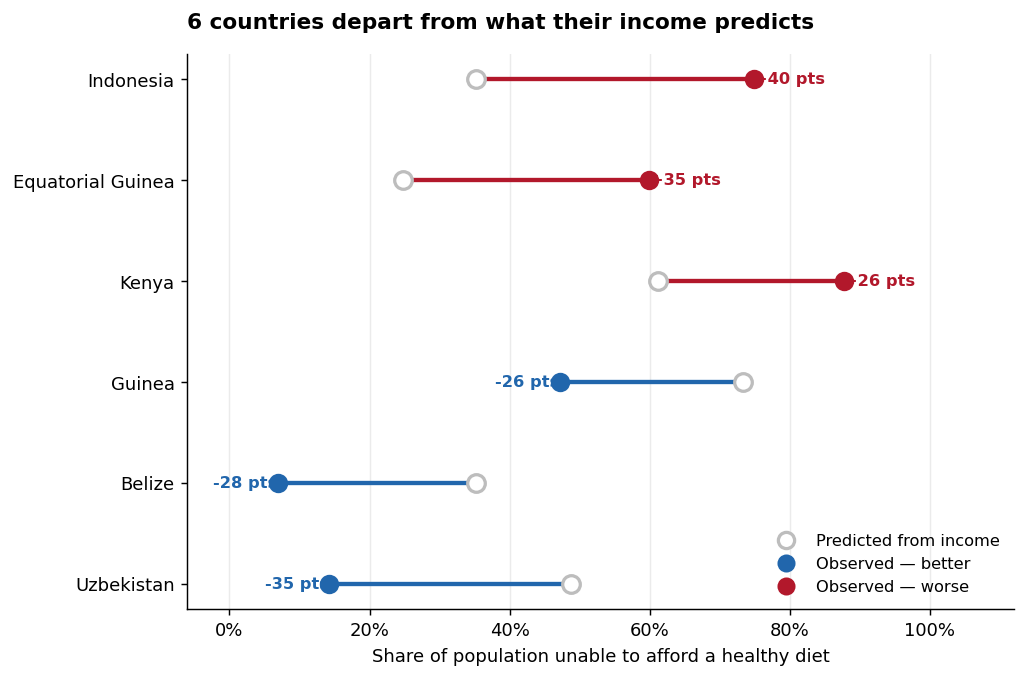

In [ ]:
from matplotlib.lines import Line2D

d = clean.sort_values('resid_oof')
fig, ax = plt.subplots(figsize=(8, 0.62 * len(d) + 1.6))

for i, (_, r) in enumerate(d.iterrows()):
    col = BLUE if r['resid_oof'] < 0 else RED
    ax.plot([r['pred_oof'], r[TARGET]], [i, i], color=col, lw=2.4, zorder=1,
            solid_capstyle='round')
    ax.scatter(r['pred_oof'], i, s=95, facecolor='white', edgecolor=GREY,
               lw=1.8, zorder=2)
    ax.scatter(r[TARGET], i, s=95, color=col, zorder=3)

    gap = (r[TARGET] - r['pred_oof']) * 100
    off = 0.035 if r[TARGET] > r['pred_oof'] else -0.035
    ax.annotate(f'{gap:+.0f} pts', (r[TARGET], i), xytext=(off, 0),
                textcoords='offset fontsize', va='center',
                ha='left' if off > 0 else 'right',
                fontsize=9, color=col, fontweight='bold')

ax.set_yticks(range(len(d)))
ax.set_yticklabels(d['country'])
ax.set_xlabel('Share of population unable to afford a healthy diet')
ax.set_xlim(-0.06, 1.12)
ax.xaxis.set_major_formatter(lambda x, p: f'{x:.0%}')
ax.set_title(f'{len(d)} countries depart from what their income predicts',
             fontweight='bold', loc='left', pad=14)

ax.legend(handles=[
    Line2D([], [], marker='o', ls='', mfc='white', mec=GREY, mew=1.8, ms=9,
           label='Predicted from income'),
    Line2D([], [], marker='o', ls='', color=BLUE, ms=9, label='Observed — better'),
    Line2D([], [], marker='o', ls='', color=RED, ms=9, label='Observed — worse'),
], loc='lower right', frameon=False, fontsize=9)

ax.grid(axis='x', alpha=0.25)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('fig1_outlier_gaps.png', bbox_inches='tight', dpi=200)
plt.show()

### Figure 2 — Observed against predicted, outliers named

The diagnostic scatter from section 11, turned into a narrative: most countries hug the
line, and the ones that do not are named.

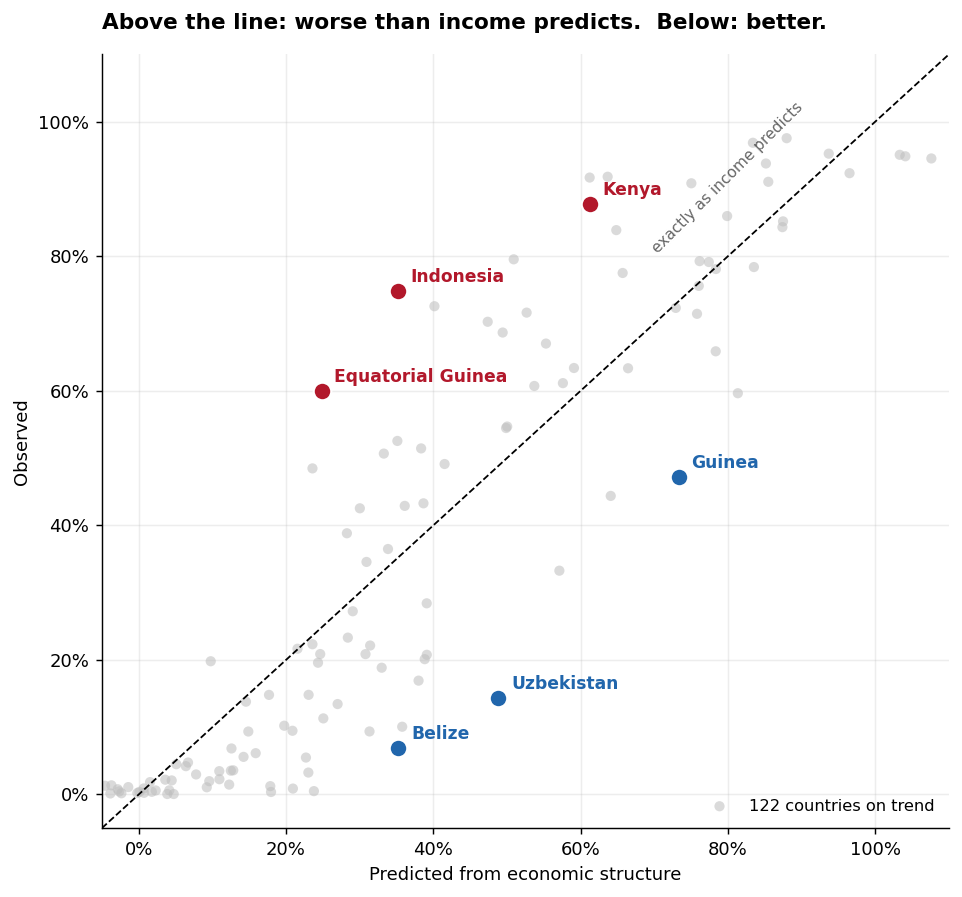

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 7))

rest = mdf[~mdf.index.isin(clean.index)]
ax.scatter(rest['pred_oof'], rest[TARGET], s=32, color=GREY, alpha=0.55,
           edgecolor='none', label=f'{len(rest)} countries on trend')

for _, r in clean.iterrows():
    col = BLUE if r['resid_oof'] < 0 else RED
    ax.scatter(r['pred_oof'], r[TARGET], s=95, color=col, zorder=3,
               edgecolor='white', lw=1.2)
    ax.annotate(r['country'], (r['pred_oof'], r[TARGET]),
                xytext=(7, 5), textcoords='offset points',
                fontsize=9.5, fontweight='bold', color=col)

lim = [-0.05, 1.10]
ax.plot(lim, lim, ls='--', color='black', lw=1, zorder=1)
ax.annotate('exactly as income predicts', (0.80, 0.80), rotation=45,
            fontsize=8.5, color='black', ha='center', va='bottom', alpha=0.6)

ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Predicted from economic structure')
ax.set_ylabel('Observed')
ax.xaxis.set_major_formatter(lambda x, p: f'{x:.0%}')
ax.yaxis.set_major_formatter(lambda x, p: f'{x:.0%}')
ax.set_title('Above the line: worse than income predicts.  Below: better.',
             fontweight='bold', loc='left', pad=14)
ax.legend(loc='lower right', frameon=False, fontsize=9)
ax.grid(alpha=0.22)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('fig2_observed_vs_predicted.png', bbox_inches='tight', dpi=200)
plt.show()

### Figure 3 — One variable carries the model

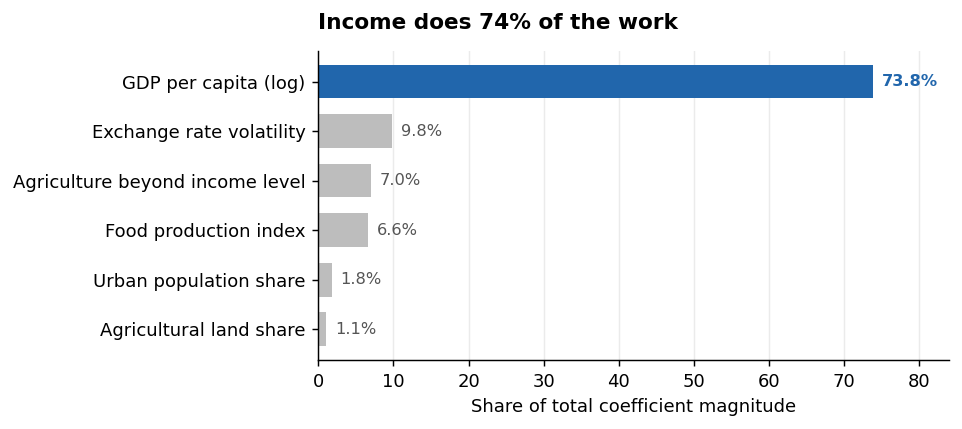

In [ ]:
share = (coefs.abs() / coefs.abs().sum()).sort_values()

LABELS = {
    'gdp_pc_ppp_log': 'GDP per capita (log)',
    'fx_volatility_log': 'Exchange rate volatility',
    'agri_excess': 'Agriculture beyond income level',
    'food_production_index': 'Food production index',
    'urban_share': 'Urban population share',
    'agri_land_share': 'Agricultural land share',
}

fig, ax = plt.subplots(figsize=(7.5, 3.4))
top = share.max()
cols = [BLUE if v == top else GREY for v in share]
ax.barh([LABELS.get(i, i) for i in share.index], share * 100, color=cols, height=0.68)

for i, v in enumerate(share * 100):
    ax.text(v + 1.2, i, f'{v:.1f}%', va='center', fontsize=9,
            fontweight='bold' if v == top * 100 else 'normal',
            color=BLUE if v == top * 100 else '#555555')

ax.set_xlabel('Share of total coefficient magnitude')
ax.set_xlim(0, 84)
ax.set_title(f'Income does {top:.0%} of the work',
             fontweight='bold', loc='left', pad=12)
ax.grid(axis='x', alpha=0.25)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('fig3_coefficient_share.png', bbox_inches='tight', dpi=200)
plt.show()

### Figure 4 — Deviation across the income range

Makes the scope condition visible rather than asserted: countries near 0% or 100% have no
room to deviate, so every robust outlier sits in the middle.

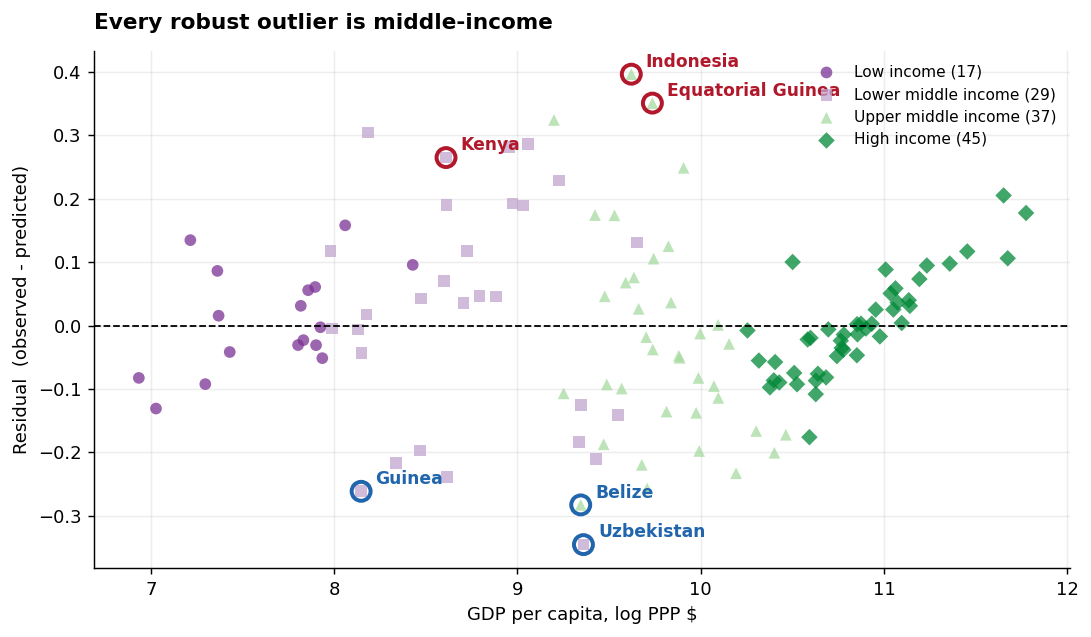

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 5))

ORDER = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
MARK = {'Low income': 'o', 'Lower middle income': 's',
        'Upper middle income': '^', 'High income': 'D'}
SHADE = {'Low income': '#7b3294', 'Lower middle income': '#c2a5cf',
         'Upper middle income': '#a6dba0', 'High income': '#008837'}

for grp in ORDER:
    sub = mdf[mdf['income_group'] == grp]
    if len(sub):
        ax.scatter(sub['gdp_pc_ppp_log'], sub['resid_oof'], s=42,
                   marker=MARK.get(grp, 'o'), color=SHADE.get(grp, GREY),
                   alpha=0.75, edgecolor='none', label=f'{grp} ({len(sub)})')

for _, r in clean.iterrows():
    col = BLUE if r['resid_oof'] < 0 else RED
    ax.scatter(r['gdp_pc_ppp_log'], r['resid_oof'], s=110, facecolor='none',
               edgecolor=col, lw=2.2, zorder=4)
    ax.annotate(r['country'], (r['gdp_pc_ppp_log'], r['resid_oof']),
                xytext=(8, 4), textcoords='offset points',
                fontsize=9.5, fontweight='bold', color=col)

ax.axhline(0, color='black', lw=1, ls='--')
ax.set_xlabel('GDP per capita, log PPP $')
ax.set_ylabel('Residual  (observed - predicted)')
ax.set_title('Every robust outlier is middle-income',
             fontweight='bold', loc='left', pad=12)
ax.legend(loc='upper right', frameon=False, fontsize=8.5)
ax.grid(alpha=0.22)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('fig4_residual_by_income.png', bbox_inches='tight', dpi=200)
plt.show()

## 13. Save

In [ ]:
out = mdf[['iso3', 'country', 'region', 'income_group', 'year',
           TARGET, 'pred', 'pred_oof', 'resid', 'resid_oof', 'resid_z',
           'boot_rate', 'spec_rate', 'stable', 'years_stale',
           'gap_vs_published'] + FEATURES]

out.to_csv(CACHE / 'residuals.csv', index=False)
print(f'saved residuals.csv: {len(out)} countries')

!zip -qr data_cache.zip data_cache
!cp data_cache.zip /content/drive/MyDrive/
print('data_cache.zip updated in Drive')

saved residuals.csv: 128 countries
data_cache.zip updated in Drive
